# Uber Ride Cancellation Prediction - Data Preparation

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
file_path = '/Users/Disha/Desktop/Projects/Uber/Uber_Booking_2024.xlsx'
df = pd.read_excel(file_path, sheet_name='Booking_Details')

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Dataset loaded: 150,000 rows, 21 columns
Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00


In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

## Data Cleaning

In [5]:
duplicates = df['Booking ID'].duplicated().sum()
print(f"Duplicate booking IDs found: {duplicates:,}")

df_clean = df.drop_duplicates(subset=['Booking ID'], keep='first')
print(f"Records after removing duplicates: {len(df_clean):,}")

Duplicate booking IDs found: 1,233
Records after removing duplicates: 148,767


In [6]:
missing_summary = df_clean.isnull().sum()
missing_summary[missing_summary > 0].sort_values(ascending=False)

Incomplete Rides                     139840
Incomplete Rides Reason              139840
Cancelled Rides by Customer          138365
Reason for cancelling by Customer    138365
Cancelled Rides by Driver            121978
Driver Cancellation Reason           121978
Driver Ratings                        56519
Customer Rating                       56519
Avg CTAT                              47592
Booking Value                         47592
Ride Distance                         47592
Payment Method                        47592
Avg VTAT                              10401
dtype: int64

**Note:** Missing values in Booking Value, Ride Distance, and Ratings are expected for cancelled/incomplete rides. These fields only contain data for completed rides.

## Exploratory Data Analysis

In [7]:
# Target variable distribution
target_dist = df_clean['Booking Status'].value_counts()
target_pct = df_clean['Booking Status'].value_counts(normalize=True) * 100

print("Booking Status Distribution:")
print("-" * 50)
for status in target_dist.index:
    count = target_dist[status]
    pct = target_pct[status]
    print(f"{status:25s}: {count:7,} ({pct:5.1f}%)")

Booking Status Distribution:
--------------------------------------------------
Completed                :  92,248 ( 62.0%)
Cancelled by Driver      :  26,789 ( 18.0%)
Cancelled by Customer    :  10,402 (  7.0%)
No Driver Found          :  10,401 (  7.0%)
Incomplete               :   8,927 (  6.0%)


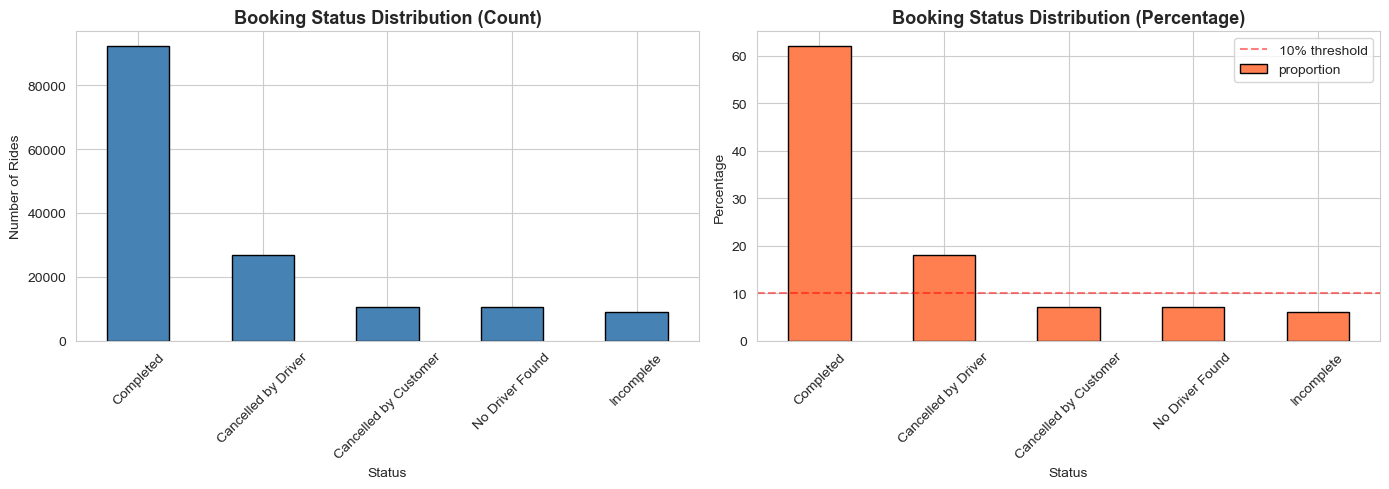

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Booking Status Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Rides')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
target_pct.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Booking Status Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Vehicle type distribution
print("Vehicle Type Distribution:")
print(df_clean['Vehicle Type'].value_counts())

Vehicle Type Distribution:
Vehicle Type
Auto             37129
Go Mini          29556
Go Sedan         26934
Bike             22318
Premier Sedan    17950
eBike            10458
Uber XL           4422
Name: count, dtype: int64


In [10]:
# Payment method distribution
print("Payment Method Distribution:")
print(df_clean['Payment Method'].value_counts())

Payment Method Distribution:
Payment Method
UPI            45542
Cash           25157
Uber Wallet    12174
Credit Card    10119
Debit Card      8183
Name: count, dtype: int64


## Feature Engineering

### Temporal Features

In [11]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Time'] = pd.to_datetime(df_clean['Time'], format='%H:%M:%S').dt.time

df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['day'] = df_clean['Date'].dt.day
df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek  # Monday=0, Sunday=6
df_clean['hour'] = pd.to_datetime(df_clean['Time'], format='%H:%M:%S').dt.hour

In [12]:
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)
df_clean['is_peak_hour'] = ((df_clean['hour'].between(7, 10)) | 
                             (df_clean['hour'].between(17, 21))).astype(int)

# Time of day categories
def categorize_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_of_day'] = df_clean['hour'].apply(categorize_time_of_day)

In [13]:
print("Weekend distribution:")
print(df_clean['is_weekend'].value_counts())
print("\nPeak hour distribution:")
print(df_clean['is_peak_hour'].value_counts())
print("\nTime of day distribution:")
print(df_clean['time_of_day'].value_counts())

Weekend distribution:
is_weekend
0    106158
1     42609
Name: count, dtype: int64

Peak hour distribution:
is_peak_hour
1    81670
0    67097
Name: count, dtype: int64

Time of day distribution:
time_of_day
Morning      45069
Evening      43772
Afternoon    37041
Night        22885
Name: count, dtype: int64


### Categorical Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns to encode
categorical_cols = ['Vehicle Type', 'Pickup Location', 'Drop Location', 
                    'Payment Method', 'time_of_day']

# Store encoders for later use
label_encoders = {}

for col in categorical_cols:
    # Handle missing values
    df_clean[col] = df_clean[col].fillna('Unknown')
    
    # Create and apply label encoder
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    
    print(f"Encoded {col}: {df_clean[col].nunique()} unique values")

Encoded Vehicle Type: 7 unique values
Encoded Pickup Location: 176 unique values
Encoded Drop Location: 176 unique values
Encoded Payment Method: 6 unique values
Encoded time_of_day: 4 unique values


In [15]:
print("Vehicle Type encoding:")
vehicle_mapping = dict(zip(label_encoders['Vehicle Type'].classes_, 
                           label_encoders['Vehicle Type'].transform(label_encoders['Vehicle Type'].classes_)))
for k, v in vehicle_mapping.items():
    print(f"  {k:20s} -> {v}")

Vehicle Type encoding:
  Auto                 -> 0
  Bike                 -> 1
  Go Mini              -> 2
  Go Sedan             -> 3
  Premier Sedan        -> 4
  Uber XL              -> 5
  eBike                -> 6


### Feature Selection

In [16]:
# Features available at booking time 
feature_cols = [
    # Temporal features
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
    
    # Categorical features (encoded)
    'Vehicle Type_encoded', 'Pickup Location_encoded', 
    'Drop Location_encoded', 'Payment Method_encoded', 'time_of_day_encoded'
]

# Create feature matrix
X = df_clean[feature_cols].copy()

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_clean['Booking Status'])

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nNo missing values in features: {X.isnull().sum().sum() == 0}")

Feature matrix shape: (148767, 10)
Target vector shape: (148767,)

No missing values in features: True


In [17]:
X.describe()

,hour,day_of_week,month,is_weekend,is_peak_hour,Vehicle Type_encoded,Pickup Location_encoded,Drop Location_encoded,Payment Method_encoded,time_of_day_encoded
count,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000,148767.000000
mean,14.034941,2.997641,6.491977,0.286414,0.548979,2.143553,87.522226,87.578314,3.023298,1.361626
std,5.416712,2.003439,3.443618,0.452087,0.497597,1.784296,50.855899,50.756378,1.791637,1.018084
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,1.000000,4.000000,0.000000,0.000000,1.000000,43.000000,44.000000,2.000000,1.000000
50%,15.000000,3.000000,7.000000,0.000000,1.000000,2.000000,88.000000,88.000000,3.000000,1.000000
75%,18.000000,5.000000,9.000000,1.000000,1.000000,3.000000,132.000000,131.000000,5.000000,2.000000
max,23.000000,6.000000,12.000000,1.000000,1.000000,6.000000,175.000000,175.000000,5.000000,3.000000


In [18]:
print("Target variable encoding:")
target_mapping = dict(zip(target_encoder.classes_, 
                         target_encoder.transform(target_encoder.classes_)))
for k, v in target_mapping.items():
    print(f"  {k:25s} -> {v}")

Target variable encoding:
  Cancelled by Customer     -> 0
  Cancelled by Driver       -> 1
  Completed                 -> 2
  Incomplete                -> 3
  No Driver Found           -> 4


## Train-Validation-Test Split

In [19]:
# Define split dates
train_end = pd.Timestamp('2024-09-30')
val_end = pd.Timestamp('2024-10-31')

# Create time-based masks
train_mask = df_clean['Date'] <= train_end
val_mask = (df_clean['Date'] > train_end) & (df_clean['Date'] <= val_end)
test_mask = df_clean['Date'] > val_end

# Split data
X_train = X[train_mask].copy()
y_train = y[train_mask].copy()

X_val = X[val_mask].copy()
y_val = y[val_mask].copy()

X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

print("Split sizes:")
print(f"Training:   {len(X_train):7,} samples ({len(X_train)/len(X)*100:5.1f}%)")
print(f"Validation: {len(X_val):7,} samples ({len(X_val)/len(X)*100:5.1f}%)")
print(f"Test:       {len(X_test):7,} samples ({len(X_test)/len(X)*100:5.1f}%)")

Split sizes:
Training:   111,771 samples ( 75.1%)
Validation:  12,547 samples (  8.4%)
Test:        24,449 samples ( 16.4%)


In [20]:
def show_class_distribution(y_data, set_name):
    print(f"\n{set_name}:")
    unique, counts = np.unique(y_data, return_counts=True)
    for val, count in zip(unique, counts):
        class_name = target_encoder.inverse_transform([val])[0]
        pct = count / len(y_data) * 100
        print(f"  {class_name:25s}: {count:6,} ({pct:5.1f}%)")

show_class_distribution(y_train, "Training Set")
show_class_distribution(y_val, "Validation Set")
show_class_distribution(y_test, "Test Set")


Training Set:
  Cancelled by Customer    :  7,798 (  7.0%)
  Cancelled by Driver      : 20,186 ( 18.1%)
  Completed                : 69,249 ( 62.0%)
  Incomplete               :  6,678 (  6.0%)
  No Driver Found          :  7,860 (  7.0%)

Validation Set:
  Cancelled by Customer    :    888 (  7.1%)
  Cancelled by Driver      :  2,206 ( 17.6%)
  Completed                :  7,842 ( 62.5%)
  Incomplete               :    751 (  6.0%)
  No Driver Found          :    860 (  6.9%)

Test Set:
  Cancelled by Customer    :  1,716 (  7.0%)
  Cancelled by Driver      :  4,397 ( 18.0%)
  Completed                : 15,157 ( 62.0%)
  Incomplete               :  1,498 (  6.1%)
  No Driver Found          :  1,681 (  6.9%)


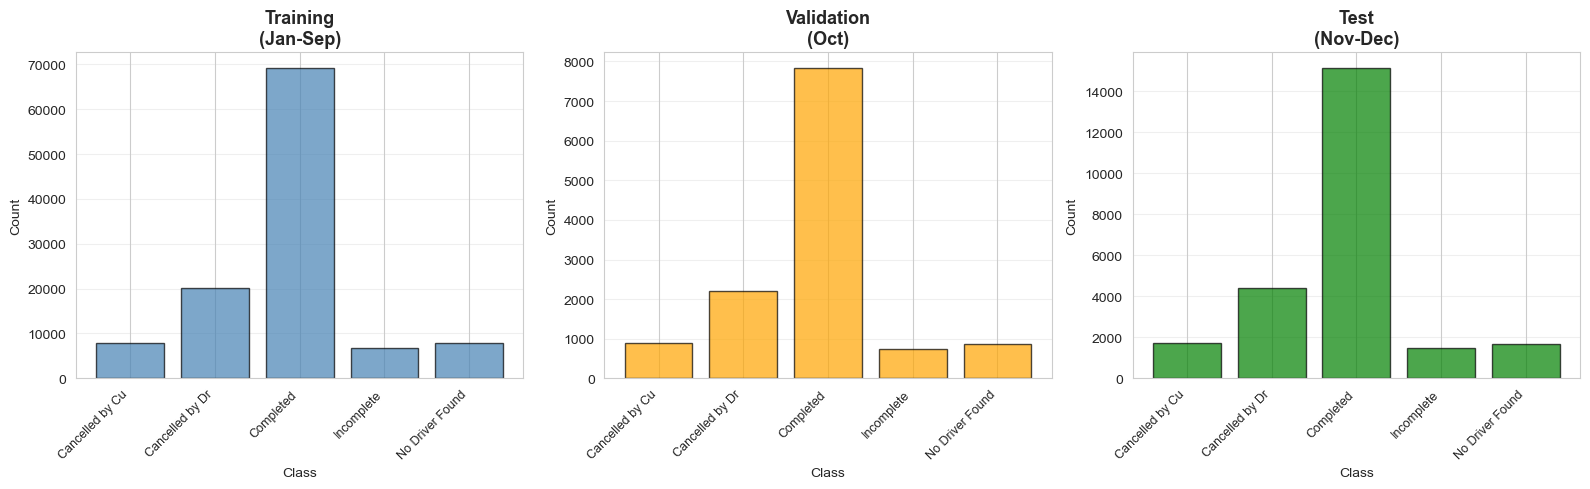

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [(y_train, 'Training\n(Jan-Sep)', 'steelblue'),
            (y_val, 'Validation\n(Oct)', 'orange'),
            (y_test, 'Test\n(Nov-Dec)', 'green')]

for idx, (y_data, title, color) in enumerate(datasets):
    unique, counts = np.unique(y_data, return_counts=True)
    labels = [target_encoder.inverse_transform([v])[0][:15] for v in unique]
    
    axes[idx].bar(range(len(unique)), counts, color=color, edgecolor='black', alpha=0.7)
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticks(range(len(unique)))
    axes[idx].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Save Prepared Data

In [22]:
import pickle

# Save train-val-test splits
np.save('X_train.npy', X_train.values)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val.values)
np.save('y_val.npy', y_val)
np.save('X_test.npy', X_test.values)
np.save('y_test.npy', y_test)

# Save encoders
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Data saved successfully")

Data saved successfully
